# Support Vector Machine(SVM)

## Introduction
Supervised learning method used for classification,regression and outliers detection.

## 2. Linear SVm Classification

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
import pandas as pd
from sklearn import datasets
from sklearn import svm

In [2]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
col=['petal_length','petal_width','species']
df.loc[:,col].head()

,petal_length,petal_width,species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


In [4]:
df.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [8]:
col=['petal_length','petal_width']
X=df.loc[:,col]

In [9]:
#it is difficult to work with specific names, so we convert or map them with some integers.
species_to_num={'setosa':0,
                'versicolor':1,
                'virginica':2}
df['tmp']=df['species'].map(species_to_num)
y=df['tmp']

In [10]:
# Modelling:
C=0.001
clf=svm.SVC(kernel='linear',C=C)
#clf=svm.LinearSVC(C=C,loss='hinge')
#clf=svm.SVC(kernel='poly',degree=3,C=C)
#clf=svm.SVC(kernel='rbf',gamma=0.7,C=C)
clf.fit(X,y)

,C,0.001
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [11]:
clf.predict([[6,2]])

C:\Users\ADMIN\anaconda3\envs\ML_Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([2])

In [14]:
Xv=X.values.reshape(-1,1)
h=0.02
x_min,x_max=Xv.min(),Xv.max()+1
y_min,y_max=y.min(),y.max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),
                  np.arange(y_min,y_max,h))

C:\Users\ADMIN\anaconda3\envs\ML_Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


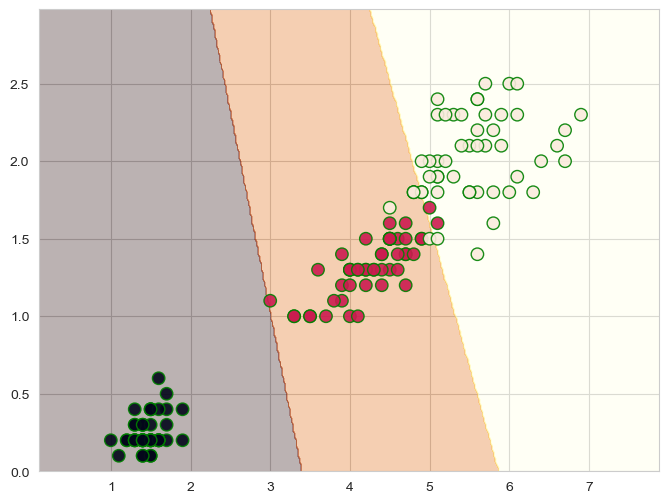

In [15]:
z=clf.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)
fig=plt.figure(figsize=(8,6))
ax=plt.contourf(xx,yy,z,cmap='afmhot',alpha=0.3)
plt.scatter(X.values[:,0],X.values[:,1],c=y,s=80,
            alpha=0.9,edgecolor='g')

## Linear SVM Implementation

In [16]:
df=sns.load_dataset('iris')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
col=['petal_length','petal_width']
X=df.loc[:,col]
species_to_num={'setosa':0,
                'versicolor':1,
                'virginica':2}
df['tmp']=df['species'].map(species_to_num)
y=df['tmp']
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               train_size=0.8,
                                               random_state=0)

### Scale Features:

In [17]:
sc_x=StandardScaler()
X_std_train=sc_x.fit_transform(X_train)

In [18]:
C=1.0
clf=svm.SVC(kernel='linear',C=C)
clf.fit(X_std_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [19]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score,recall_score,f1_score

### Cross Validation within Train Dataset

In [20]:
res=cross_val_score(clf,X_std_train,y_train,cv=10,scoring='accuracy')
print("Average Accuracy: \t{0:.4f}".format(np.mean(res)))
print("Accuracy SD:\t\t {0:.4f}".format(np.std(res)))

Average Accuracy: 	0.9500
Accuracy SD:		 0.0553


In [21]:
y_train_pred=cross_val_predict(clf,X_std_train,y_train,cv=3)

In [22]:
confusion_matrix(y_train,y_train_pred)

array([[39,  0,  0],
       [ 0, 34,  3],
       [ 0,  3, 41]])

In [23]:
print("Precision Score:\t{0:.4f}".format(precision_score(y_train,
                                                         y_train_pred,
                                                         average='weighted')))
print("Recall Score:\t\t{0:.4f}".format(recall_score(y_train,
                                                    y_train_pred,
                                                    average='weighted')))
print("F1 Score:\t\t{0:.4f}".format(f1_score(y_train,
                                             y_train_pred,
                                             average='weighted')))

Precision Score:	0.9500
Recall Score:		0.9500
F1 Score:		0.9500


### Cross Validation within Test Data

In [24]:
y_test_pred=cross_val_predict(clf,sc_x.transform(X_test),y_test,cv=3)

In [25]:
confusion_matrix(y_test,y_test_pred)

array([[11,  0,  0],
       [ 0, 13,  0],
       [ 0,  2,  4]])

In [26]:
print("Precision Score:\t{0:.4f}".format(precision_score(y_test,
                                                         y_test_pred,
                                                         average='weighted')))
print("Recall Score:\t\t{0:.4f}".format(recall_score(y_test,
                                                    y_test_pred,
                                                    average='weighted')))
print("F1 Score:\t\t{0:.4f}".format(f1_score(y_test,
                                             y_test_pred,
                                             average='weighted')))

Precision Score:	0.9422
Recall Score:		0.9333
F1 Score:		0.9290


As you observed the diference between the scores of training data cross validation and testing data cross validation is bit different.

---
## Polynomial Kernel

In [27]:
C=1.0
clf=svm.SVC(kernel='poly',degree=3,C=C,gamma='auto')
clf.fit(X,y)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [30]:
Xv=X.values.reshape(-1,1)
h=0.02
x_min,x_max=Xv.min(),Xv.max()+1
y_min,y_max=y.min(),y.max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),
                  np.arange(y_min,y_max,h))

C:\Users\ADMIN\anaconda3\envs\ML_Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


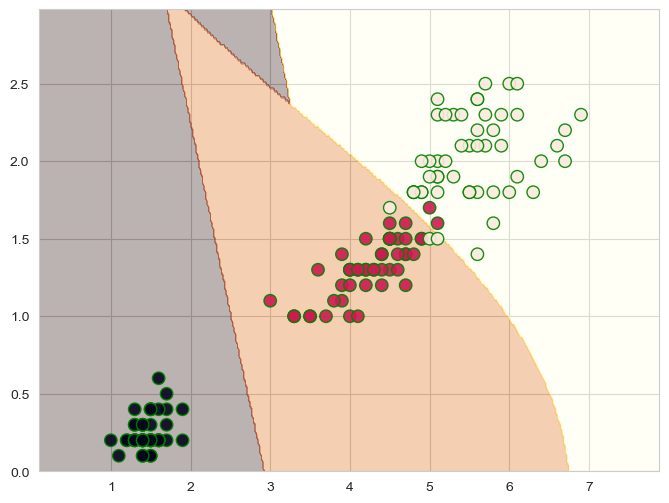

In [31]:
z=clf.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)
fig=plt.figure(figsize=(8,6))
ax=plt.contourf(xx,yy,z,cmap='afmhot',alpha=0.3)
plt.scatter(X.values[:,0],X.values[:,1],c=y,s=80,
            alpha=0.9,edgecolor='g')

## Polynomial SVM Implementation

In [32]:
df=sns.load_dataset('iris')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
col=['petal_length','petal_width']
X=df.loc[:,col]
species_to_num={'setosa':0,
                'versicolor':1,
                'virginica':2}
df['tmp']=df['species'].map(species_to_num)
y=df['tmp']
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               train_size=0.8,
                                               random_state=0)

### Scale Features

In [33]:
sc_x=StandardScaler()
X_std_train=sc_x.fit_transform(X_train)

In [34]:
C=1.0
clf=svm.SVC(kernel='poly',degree=10,C=C,gamma='auto')
clf.fit(X_std_train,y_train)

,C,1.0
,kernel,'poly'
,degree,10
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Cross Validation within Train Dataset

In [35]:
res=cross_val_score(clf,X_std_train,y_train,cv=10,scoring='accuracy')
print("Average Accuracy: \t{0:.4f}".format(np.mean(res)))
print("Accuracy SD:\t\t {0:.4f}".format(np.std(res)))

Average Accuracy: 	0.7833
Accuracy SD:		 0.1404


In [36]:
y_train_pred=cross_val_predict(clf,X_std_train,y_train,cv=3)

In [37]:
confusion_matrix(y_train,y_train_pred)

array([[35,  0,  4],
       [ 0, 37,  0],
       [ 7, 18, 19]])

In [38]:
print("Precision Score:\t{0:.4f}".format(precision_score(y_train,
                                                         y_train_pred,
                                                         average='weighted')))
print("Recall Score:\t\t{0:.4f}".format(recall_score(y_train,
                                                    y_train_pred,
                                                    average='weighted')))
print("F1 Score:\t\t{0:.4f}".format(f1_score(y_train,
                                             y_train_pred,
                                             average='weighted')))

Precision Score:	0.7812
Recall Score:		0.7583
F1 Score:		0.7368


### Cross Validation within test data

In [39]:
y_test_pred=cross_val_predict(clf,sc_x.transform(X_test),y_test,cv=3)

In [40]:
confusion_matrix(y_test,y_test_pred)

array([[10,  0,  1],
       [ 0, 13,  0],
       [ 3,  3,  0]])

In [41]:
print("Precision Score:\t{0:.4f}".format(precision_score(y_test,
                                                         y_test_pred,
                                                         average='weighted')))
print("Recall Score:\t\t{0:.4f}".format(recall_score(y_test,
                                                    y_test_pred,
                                                    average='weighted')))
print("F1 Score:\t\t{0:.4f}".format(f1_score(y_test,
                                             y_test_pred,
                                             average='weighted')))

Precision Score:	0.6341
Recall Score:		0.7667
F1 Score:		0.6941


The above is the polynomial kernel of the previous Linear kernel,Basically it needs to improve but, it doesnt.
May be it'll be better if we change some parameters like degree,C and etc.

---
## 4.Gaussian Radial Basis Function(rbf)

In [42]:
df=sns.load_dataset('iris')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
col=['petal_length','petal_width']
X=df.loc[:,col]
species_to_num={'setosa':0,
                'versicolor':1,
                'virginica':2}
df['tmp']=df['species'].map(species_to_num)
y=df['tmp']
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               train_size=0.8,
                                               random_state=0)

### Scale Features

In [43]:
sc_x=StandardScaler()
X_std_train=sc_x.fit_transform(X_train)

In [44]:
C=1.0
clf=svm.SVC(kernel='rbf',C=C,gamma=0.7)
clf.fit(X_std_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,0.7
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


 ### Cross Validation within Train Dataset

In [45]:
res=cross_val_score(clf,X_std_train,y_train,cv=10,scoring='accuracy')
print("Average Accuracy: \t{0:.4f}".format(np.mean(res)))
print("Accuracy SD:\t\t {0:.4f}".format(np.std(res)))

Average Accuracy: 	0.9500
Accuracy SD:		 0.0553


In [46]:
y_train_pred=cross_val_predict(clf,X_std_train,y_train,cv=3)

In [47]:
confusion_matrix(y_train,y_train_pred)

array([[39,  0,  0],
       [ 0, 35,  2],
       [ 0,  3, 41]])

In [48]:
print("Precision Score:\t{0:.4f}".format(precision_score(y_train,
                                                         y_train_pred,
                                                         average='weighted')))
print("Recall Score:\t\t{0:.4f}".format(recall_score(y_train,
                                                    y_train_pred,
                                                    average='weighted')))
print("F1 Score:\t\t{0:.4f}".format(f1_score(y_train,
                                             y_train_pred,
                                             average='weighted')))

Precision Score:	0.9586
Recall Score:		0.9583
F1 Score:		0.9584


## Grid Search

In [51]:
from sklearn.pipeline import Pipeline

In [52]:
from sklearn.model_selection import train_test_split,GridSearchCV

we can improve this by scaling the features

In [53]:
pipeline=Pipeline([('clf',svm.SVC(kernel='rbf',C=1,gamma=0.1))])

In [60]:
params={'clf__C':(0.1,0.5,1,2,5,10,20),
        'clf__gamma':(0.001,0.01,0.1,0.25,0.5,0.75,1)}

In [61]:
svm_grid_rbf=GridSearchCV(pipeline,params,n_jobs=-1,
                          cv=3,verbose=1,scoring='accuracy')

In [62]:
svm_grid_rbf.fit(X_train,y_train)

Fitting 3 folds for each of 49 candidates, totalling 147 fits


,estimator,Pipeline(step... gamma=0.1))])
,param_grid,"{'clf__C': (0.1, ...), 'clf__gamma': (0.001, ...)}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.5


In [63]:
svm_grid_rbf.best_score_

np.float64(0.9583333333333334)

In [64]:
best=svm_grid_rbf.best_estimator_.get_params()

In [65]:
for k in sorted(params.keys()):
    print('\t{0}: \t{1:.2f}'.format(k,best[k]))

	clf__C: 	0.50
	clf__gamma: 	0.50


Conducting validation in the test dataset.

In [66]:
y_test_pred=svm_grid_rbf.predict(X_test)

In [67]:
confusion_matrix(y_test,y_test_pred)

array([[11,  0,  0],
       [ 0, 13,  0],
       [ 0,  0,  6]])

In [68]:
print("Precision Score:\t{0:.4f}".format(precision_score(y_test,
                                                         y_test_pred,
                                                         average='weighted')))
print("Recall Score:\t\t{0:.4f}".format(recall_score(y_test,
                                                    y_test_pred,
                                                    average='weighted')))
print("F1 Score:\t\t{0:.4f}".format(f1_score(y_test,
                                             y_test_pred,
                                             average='weighted')))

Precision Score:	1.0000
Recall Score:		1.0000
F1 Score:		1.0000


In [69]:
Xv=X.values.reshape(-1,1)
h=0.02
x_min,x_max=Xv.min(),Xv.max()+1
y_min,y_max=y.min(),y.max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),
                  np.arange(y_min,y_max,h))

C:\Users\ADMIN\anaconda3\envs\ML_Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


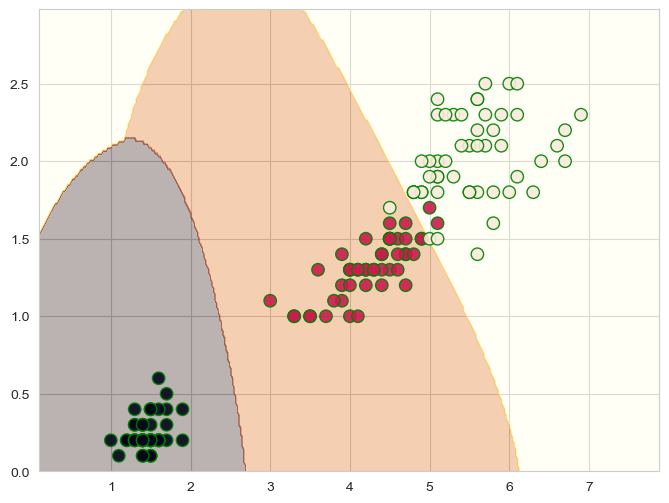

In [70]:
z=svm_grid_rbf.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)
fig=plt.figure(figsize=(8,6))
ax=plt.contourf(xx,yy,z,cmap='afmhot',alpha=0.3)
plt.scatter(X.values[:,0],X.values[:,1],c=y,s=80,
            alpha=0.9,edgecolor='g')

## Support Vector Regression

In [71]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,r2_score

In [74]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame
df= df.drop('MEDV', axis=1)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [75]:
y=boston.target
X=df[["LSTAT"]].values

In [76]:
svr=SVR(gamma='auto')
svr.fit(X,y)

,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [77]:
sort_idx=X.flatten().argsort()

Text(0, 0.5, 'MEDV')

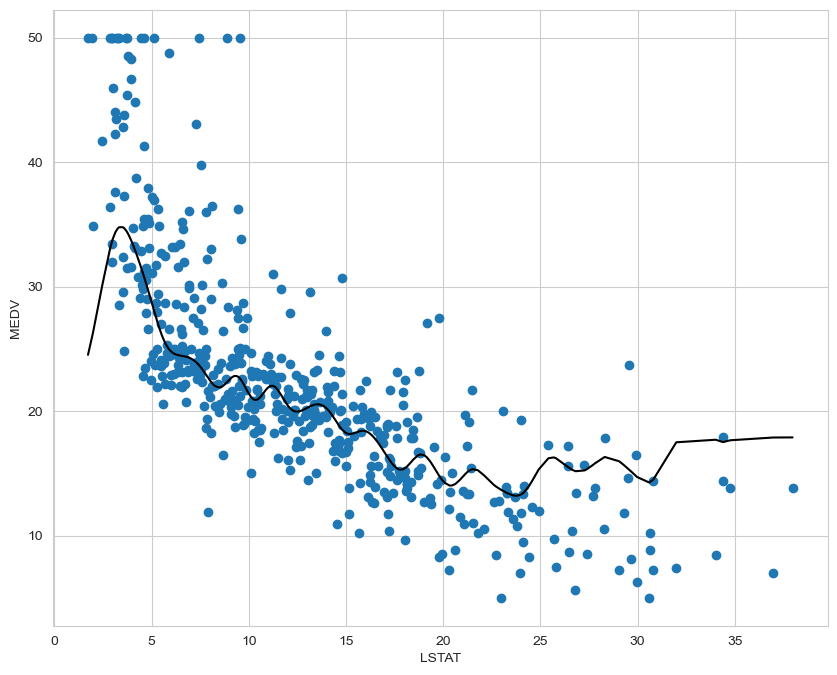

In [78]:
plt.figure(figsize=(10,8))
plt.scatter(X[sort_idx],y[sort_idx])
plt.plot(X[sort_idx],svr.predict(X[sort_idx]),color='k')
plt.xlabel("LSTAT")
plt.ylabel("MEDV")

In [79]:
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.3,
                                               random_state=42)

### Linear Kernel

In [80]:
svr=SVR(kernel='linear')
svr.fit(X_train,y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [81]:
y_train_pred=svr.predict(X_train)

In [82]:
y_test_pred=svr.predict(X_test)

In [83]:
print("MSE train:{0:.4f},test:{1:.4f}".\
      format(mean_squared_error(y_train,y_train_pred),
             mean_squared_error(y_test,y_test_pred)))

MSE train:41.8187,test:36.8372


In [84]:
print("R^2 train:{0:.4f},test:{1:.4f}".\
      format(r2_score(y_train,y_train_pred),
             r2_score(y_test,y_test_pred)))

R^2 train:0.5242,test:0.5056


### Polynomial

In [85]:
svr=SVR(kernel='poly',C=1e3,degree=2,gamma='auto')
svr.fit(X_train,y_train)

,kernel,'poly'
,degree,2
,gamma,'auto'
,coef0,0.0
,tol,0.001
,C,1000.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [86]:
y_train_pred=svr.predict(X_train)

In [87]:
y_test_pred=svr.predict(X_test)

In [88]:
print("MSE train:{0:.4f},test:{1:.4f}".\
      format(mean_squared_error(y_train,y_train_pred),
             mean_squared_error(y_test,y_test_pred)))

MSE train:110.3334,test:114.3676


In [89]:
print("R^2 train:{0:.4f},test:{1:.4f}".\
      format(r2_score(y_train,y_train_pred),
             r2_score(y_test,y_test_pred)))

R^2 train:-0.2553,test:-0.5349


### rbf Kernel

In [90]:
svr=SVR(kernel='rbf',C=1e3,gamma='auto')
svr.fit(X_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,tol,0.001
,C,1000.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [91]:
y_train_pred=svr.predict(X_train)
y_test_pred=svr.predict(X_test)

In [92]:
print("MSE train:{0:.4f},test:{1:.4f}".\
      format(mean_squared_error(y_train,y_train_pred),
             mean_squared_error(y_test,y_test_pred)))

MSE train:25.7809,test:31.4408


In [93]:
print("R^2 train:{0:.4f},test:{1:.4f}".\
      format(r2_score(y_train,y_train_pred),
             r2_score(y_test,y_test_pred)))

R^2 train:0.7067,test:0.5780


The above is modelling a machine learning by the three kernels.  
Now verify the MSE ,r2 values and compare those 3 kernels and know the better kernel for this model.